<a href="https://colab.research.google.com/github/Adithyasajeev22/Deep-Learning/blob/main/FNN(MULTI_CLASSIFICATION)_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**FEED FORWARD NEURAL NETWORK(MULTI_CLASSIFICATION)**

# **1.EDA**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/ecommerce_fashion_attribute_tagging_multiclass.csv')
df.head(5)

,product_category,brand,color,fabric_type,price,discount_percent,ratings,review_count,stock_quantity,season,seller_region,fashion_attribute_tag
0,Accessories,Adidas,White,Denim,2466.24,22,4.0,1175.0,617,Spring,North,Casual
1,Sportswear,Levis,Blue,Polyester,1247.02,57,NaN,4742.0,688,Spring,North,Casual
2,Footwear,NaN,White,Denim,3332.19,35,4.4,2297.0,146,Winter,North,Sneaker
3,Sportswear,Zara,Red,Cotton,3325.43,46,4.7,2428.0,655,Winter,East,Trending
4,Sportswear,Zara,Red,Polyester,2584.74,15,4.6,1145.0,850,Winter,South,Trending


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   product_category       500000 non-null  object 
 1   brand                  460000 non-null  object 
 2   color                  460000 non-null  object 
 3   fabric_type            500000 non-null  object 
 4   price                  500000 non-null  float64
 5   discount_percent       500000 non-null  int64  
 6   ratings                460000 non-null  float64
 7   review_count           460000 non-null  float64
 8   stock_quantity         500000 non-null  int64  
 9   season                 500000 non-null  object 
 10  seller_region          500000 non-null  object 
 11  fashion_attribute_tag  500000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 45.8+ MB


In [ ]:
df.isnull().sum()

,0
product_category,0
brand,40000
color,40000
fabric_type,0
price,0
discount_percent,0
ratings,40000
review_count,40000
stock_quantity,0
season,0


In [ ]:
df['brand'].fillna(df['brand'].mode()[0],inplace=True)
df['color'].fillna(df['color'].mode()[0],inplace=True)
df['review_count'].fillna(df['review_count'].mode()[0],inplace=True)

/tmp/ipykernel_7374/3082497308.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['brand'].fillna(df['brand'].mode()[0],inplace=True)
/tmp/ipykernel_7374/3082497308.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

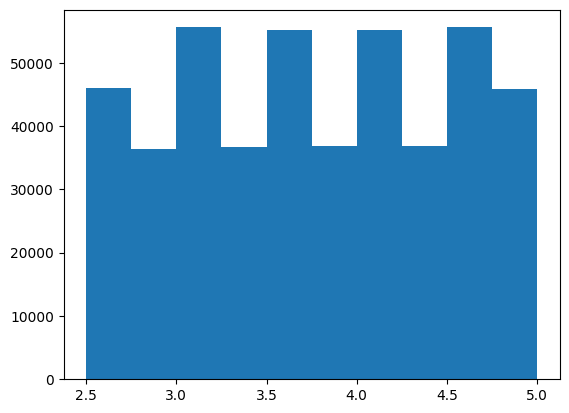

In [ ]:
plt.hist(df['ratings'])
plt.show()

In [ ]:
df['ratings'].fillna(df['ratings'].mode()[0],inplace=True)

/tmp/ipykernel_7374/77146062.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ratings'].fillna(df['ratings'].mode()[0],inplace=True)


In [ ]:
df.isnull().sum()

,0
product_category,0
brand,0
color,0
fabric_type,0
price,0
discount_percent,0
ratings,0
review_count,0
stock_quantity,0
season,0


In [ ]:
df.duplicated().sum()

np.int64(0)

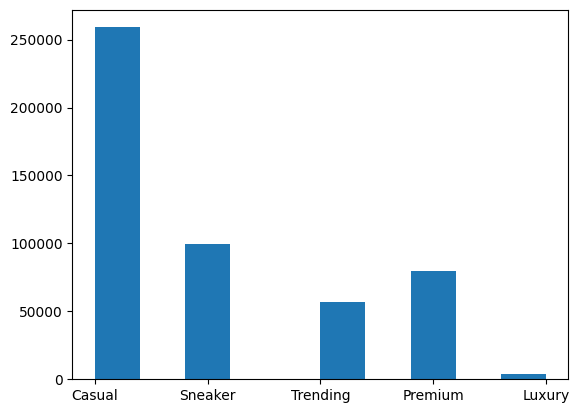

In [ ]:
plt.hist(df['fashion_attribute_tag'])
plt.show()

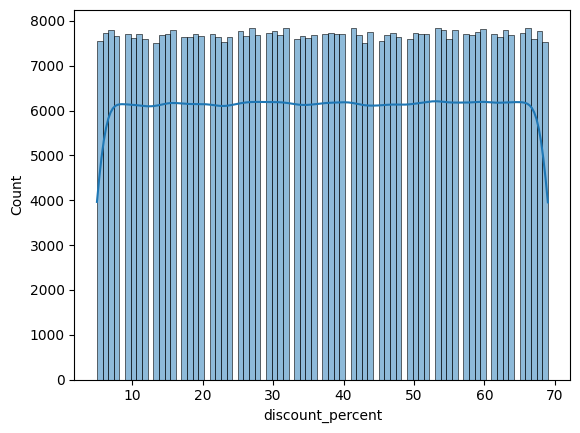

In [ ]:
sns.histplot(df['discount_percent'],kde=True)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   product_category       500000 non-null  object 
 1   brand                  500000 non-null  object 
 2   color                  500000 non-null  object 
 3   fabric_type            500000 non-null  object 
 4   price                  500000 non-null  float64
 5   discount_percent       500000 non-null  int64  
 6   ratings                500000 non-null  float64
 7   review_count           500000 non-null  float64
 8   stock_quantity         500000 non-null  int64  
 9   season                 500000 non-null  object 
 10  seller_region          500000 non-null  object 
 11  fashion_attribute_tag  500000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 45.8+ MB


In [ ]:
print(df['product_category'].unique())

['Accessories' 'Sportswear' 'Footwear' 'Women Wear' 'Men Wear']


In [ ]:
print(df['brand'].unique())

['Adidas' 'Levis' 'Puma' 'Zara' 'H&M' 'Nike' 'Gucci']


In [ ]:
print(df['color'].unique())

['White' 'Blue' 'Red' 'Pink' 'Green' 'Black']


In [ ]:
print(df['fabric_type'].unique())

['Denim' 'Polyester' 'Cotton' 'Leather' 'Silk']


In [ ]:
print(df['season'].unique())

['Spring' 'Winter' 'Summer' 'Autumn']


In [ ]:
print(df['seller_region'].unique())

['North' 'East' 'South' 'West']


In [ ]:
print(df['fashion_attribute_tag'].unique())

['Casual' 'Sneaker' 'Trending' 'Premium' 'Luxury']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['product_category']=le.fit_transform(df['product_category'])
df['fashion_attribute_tag']=le.fit_transform(df['fashion_attribute_tag'])
df['seller_region']=le.fit_transform(df['seller_region'])
df['season']=le.fit_transform(df['season'])
df['fabric_type']=le.fit_transform(df['fabric_type'])
df['color']=le.fit_transform(df['color'])
df['brand']=le.fit_transform(df['brand'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   product_category       500000 non-null  int64  
 1   brand                  500000 non-null  int64  
 2   color                  500000 non-null  int64  
 3   fabric_type            500000 non-null  int64  
 4   price                  500000 non-null  float64
 5   discount_percent       500000 non-null  int64  
 6   ratings                500000 non-null  float64
 7   review_count           500000 non-null  float64
 8   stock_quantity         500000 non-null  int64  
 9   season                 500000 non-null  int64  
 10  seller_region          500000 non-null  int64  
 11  fashion_attribute_tag  500000 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 45.8 MB


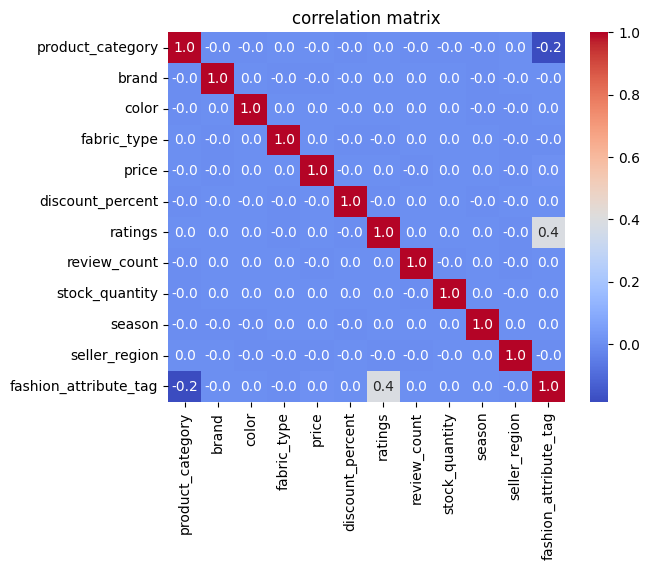

In [ ]:
corr_matrix=df.corr()

sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("correlation matrix")
plt.show()

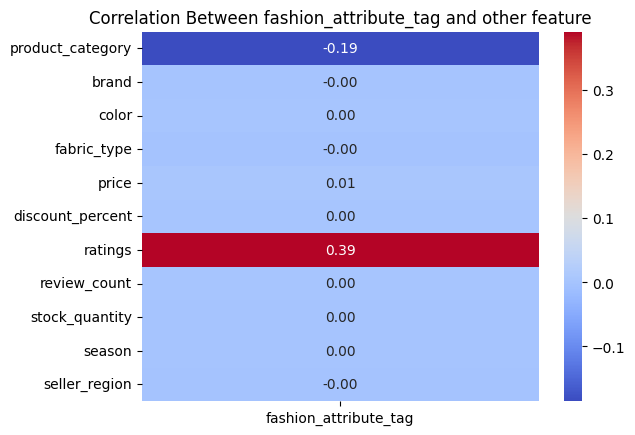

In [ ]:
status_corr=df.corr()['fashion_attribute_tag']
status_corr=status_corr.drop('fashion_attribute_tag')

sns.heatmap(status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation Between fashion_attribute_tag and other feature')
plt.show()

In [ ]:
df.drop(['product_category','brand','fabric_type','seller_region'],axis=1,inplace=True)

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr

    df=df[(df[col] >=lower_bound)& (df[col] <=upper_bound)]
  return df

df_cleaned=remove_outliers_iqr(df,exclude_column='fashion_attribute_tag')
df=df_cleaned

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=[ 'color',  'price',
       'discount_percent', 'ratings', 'review_count', 'stock_quantity',
       'season', ]

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[[ 'color', 'price',
       'discount_percent', 'ratings', 'review_count', 'stock_quantity',
       'season']]
y=df['fashion_attribute_tag']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline Model Accuracy:{accuracy:.2f}')

Baseline Model Accuracy:0.52


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# **2.FNN**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

# Defining the ANN model
model = Sequential()
model.add(Dense(90, input_shape=(7,), activation='relu'))  # Hidden Layer 1: Changed input_dim from 10 to 9
model.add(Dense(30, activation='relu'))   # Hidden Layer 2
model.add(Dense(30, activation='relu'))   # Hidden Layer 3

model.add(Dense(5, activation='softmax'))             # Output Layer: Changed units from 1 to 5 for 5 classes

# Compiling the model
model.compile(loss='SparseCategoricalCrossentropy', optimizer='adam', metrics=[SparseCategoricalAccuracy()])

# Training the model
model.fit(x_train, y_train, epochs=5)

# Evaluating the model
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f'\n Test Accuracy: {test_acc}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
11678/11678 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 1.6804 - sparse_categorical_accuracy: 0.4711
Epoch 2/5
11678/11678 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 1.2350 - sparse_categorical_accuracy: 0.5202
Epoch 3/5
11678/11678 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - loss: 1.2350 - sparse_categorical_accuracy: 0.5202
Epoch 4/5
11678/11678 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - loss: 1.2349 - sparse_categorical_accuracy: 0.5202
Epoch 5/5
11678/11678 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 1.2349 - sparse_categorical_accuracy: 0.5202
3893/3893 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2337 - sparse_categorical_accuracy: 0.5197

 Test Accuracy: 0.5196657180786133
